# Joint Energy-Based Model (JEM) Pipeline Execution

This notebook demonstrates the end-to-end execution of the Tabular JEM architecture for the Home Credit Default Risk dataset.

It covers:
1. Data Loading & Splitting
2. Model Initialization (Architecture, Replay Buffer, SGLD Sampler)
3. The Training Loop
4. Custom Metrics (Gini Stability)
5. Advanced Energy Diagnostics and Visualizations

In [1]:
import os
import sys
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure the 'src' module can be imported
sys.path.append(os.path.abspath('..'))

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

from src.model.jem.data_utils import (
    split_data_chronologically,
    get_dataloaders,
    get_latent_dataloaders
)


## 1. Data Loading and Preparation
We load the unscaled parquet file generated by the polars data pipeline.
We'll split the data into a training set and a validation set chronologically (e.g. reserving the last couple of months or weeks for validation to accurately test stability).

In [2]:
from src.data.pipeline import run_pipeline
from src.data.config import DataPipelineConfig

cfg = DataPipelineConfig(
    data_dir="../data/raw/home-credit-credit-risk-model-stability.zip",
    sample_ratio=0.1,  
    cache_dir="../.cache",
    artifact_dir="../models/artifacts"
)

df_rebuilt = run_pipeline(
    config=cfg,
    depth_0_tables=["train_static_0", "train_static_cb_0"],
    depth_1_tables=[
        "train_person_1",
        "train_deposit",
        "train_debitcard",
        "train_other",
    ],
    depth_2_tables=[],
)

df_full = df_rebuilt
print(f"Dynamically Rebuilt Data Shape: {df_full.shape}")


In [3]:
import os
train_path = "../data/processed/latent_train.pt"
val_path = "../data/processed/latent_val.pt"

if os.path.exists(train_path):
    print("Loading precomputed latent space tensors (Track B)...")
    train_loader, val_loader = get_latent_dataloaders(train_path, val_path, batch_size=256)
    input_dim = 128
else:
    print("Latent data not found. Falling back to raw feature training...")
    df_train, df_val = split_data_chronologically(df_full, val_weeks=12)
    train_loader, val_loader, scaler, feature_cols = get_dataloaders(df_train, df_val, batch_size=256)
    input_dim = len(feature_cols)

print(f"Using input dimension: {input_dim}")


## 2. Model Initialization
We initialize the core components of the Joint Energy-Based Model based on our configuration.

In [4]:
from src.model.jem.config import JEMConfig
from src.model.jem.model import TabularJEM
from src.model.jem.sampler import SGLDReplayBuffer, SGLDSampler
from src.model.jem.loss import JEMLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

config = JEMConfig(
    hidden_dims=[128, 64, 32],
    spectral_norm=True,
    sgld_steps=20,
    sgld_step_size=0.009,
    sgld_sigma=0.03,
    l2_energy_weight=1e-3,
    reinit_freq=0.05
)

model = TabularJEM(input_dim=input_dim, num_classes=2, config=config).to(device)
buffer = SGLDReplayBuffer(buffer_size=10000, feature_dim=input_dim)
sampler = SGLDSampler(config=config)
criterion = JEMLoss(config=config)


## 3. Training Loop
Run the dual-objective training.

In [5]:
from src.model.jem.train import train_jem_epoch, evaluate_jem

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
epochs = 10
history = {
    "train_loss": [], "val_stability": [],
    "e_real_train": [], "e_fake_train": [],
    "val_energies": []
}

print("Starting Training...")
for epoch in range(1, epochs + 1):
    train_logs = train_jem_epoch(model, train_loader, optimizer, criterion, buffer, sampler, device)
    val_logs = evaluate_jem(model, val_loader, device)
    
    history["train_loss"].append(train_logs["loss"])
    stability = val_logs["stability_result"]["stability_metric"]
    history["val_stability"].append(stability)
    
    history["e_real_train"].append(train_logs["gen_loss"] / 2.0) 
    history["e_fake_train"].append(-train_logs["gen_loss"] / 2.0) 
    
    if epoch == epochs:
        history["val_energies"] = val_logs["energies"]
        # Capture probabilities and labels for calibration diagnostic
        final_val_probs = val_logs["probs"]
        final_val_y = val_logs["labels"]
    
    print(f"Epoch [{(epoch):02d}/{epochs}] | Loss: {train_logs['loss']:.4f} | Validation Gini Stability: {stability:.4f}")

## 4. Diagnostics & Visualizations
Investigate specialized metrics for the JEM model.

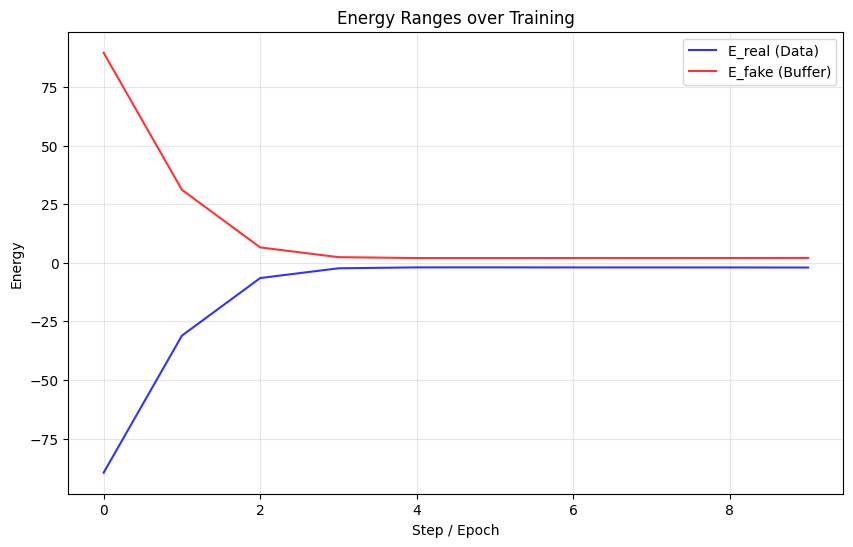

In [11]:
from src.model.jem.diagnostics import JEMDiagnostics
import os
os.makedirs("../docs/assets/", exist_ok=True)

# 1. Energy Ranges over Training
JEMDiagnostics.plot_energy_ranges(
    history["e_real_train"], 
    history["e_fake_train"],
    save_path="../docs/assets/energy_ranges.png"
)
display(Image(filename="../docs/assets/energy_ranges.png"))

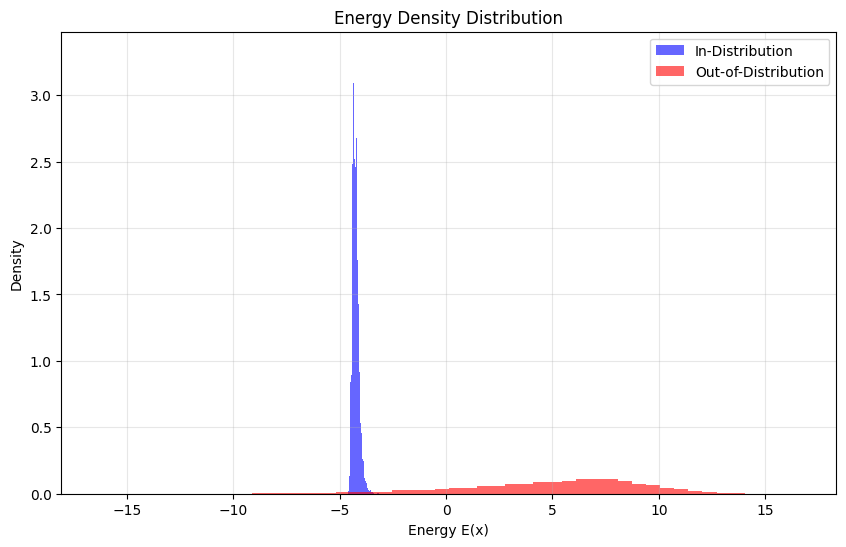

In [12]:
# 2. Energy Density Distribution
simulated_ood = []
model.eval()
with torch.no_grad():
    for x_real, _, _ in val_loader:
        x_ood = x_real + torch.randn_like(x_real) * 10.0
        ood_energies = model.compute_energy(x_ood.to(device))
        simulated_ood.append(ood_energies.cpu().numpy())

sim_ood_np = np.concatenate(simulated_ood)
JEMDiagnostics.plot_energy_density(
    history["val_energies"], 
    e_out_dist=sim_ood_np, 
    save_path="../docs/assets/energy_density.png"
)
display(Image(filename="../docs/assets/energy_density.png"))

In [13]:
# 3. Reliability Diagram (Calibration Analysis)
# JEM typically produces better-calibrated probabilities than pure Softmax classifiers.
JEMDiagnostics.plot_reliability_diagram(
    final_val_y, 
    final_val_probs, 
    save_path="../docs/assets/reliability_diag.png"
)
display(Image(filename="../docs/assets/reliability_diag.png"))

NameError: name 'final_val_y' is not defined

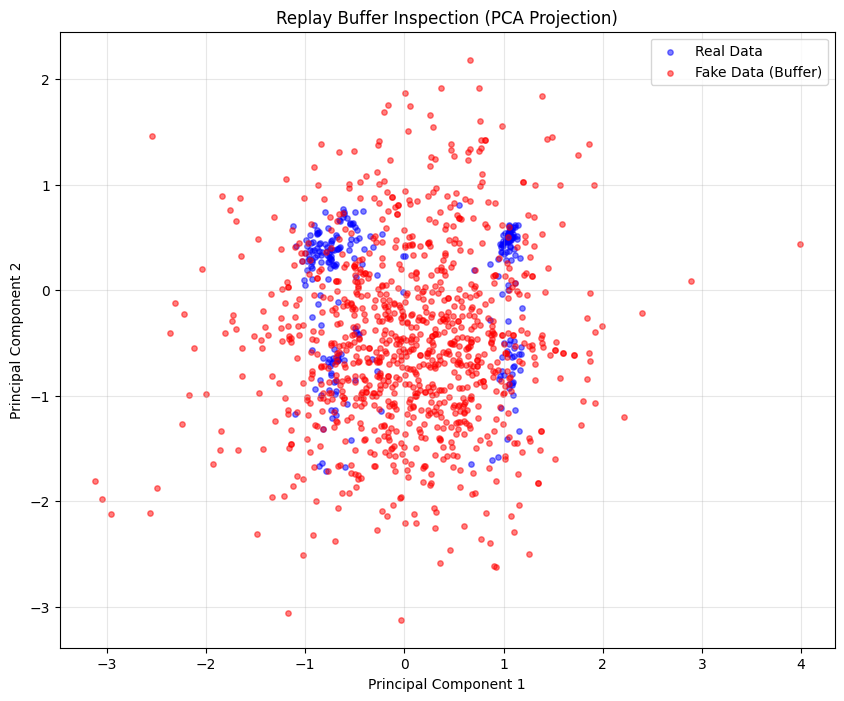

In [14]:
# 4. Replay Buffer Inspection (PCA Projection)
# Ensures the generated SGLD samples are aligned with the data manifold.
last_batch_x, _, _ = next(iter(val_loader))
JEMDiagnostics.inspect_replay_buffer(
    buffer, 
    last_batch_x, 
    save_path="../docs/assets/buffer_inspection.png"
)
display(Image(filename="../docs/assets/buffer_inspection.png"))

## 5. Model Persistence for Inference
Save artifacts for the standalone inference pipeline.

In [10]:
import os
import shutil

artifact_dir = "../models/artifacts"
os.makedirs(artifact_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(artifact_dir, "jem_model.pth"))

if 'ae' in locals():
    torch.save(ae.state_dict(), os.path.join(artifact_dir, "autoencoder.pth"))
else:
    shutil.copy("../data/processed/encoder.pt", os.path.join(artifact_dir, "autoencoder.pth"))

if 'scaler' in locals():
    torch.save({
        "num_features": scaler.num_features,
        "eps": getattr(scaler, 'eps', 1e-8),
        "state_dict": scaler.state_dict()
    }, os.path.join(artifact_dir, "scaler.pth"))
else:
    shutil.copy("../data/processed/scaler.pt", os.path.join(artifact_dir, "scaler.pth"))

print(f"Artifacts saved to {artifact_dir}")

## 6. Inference and Submission
Final submission generation.

In [15]:
from src.data.pipeline import run_pipeline
from src.data.config import DataPipelineConfig
from src.model.jem.infer import load_inference_pipeline, perform_inference
from src.model.jem.data_utils import get_inference_dataloader, get_feature_cols
import polars as pl

test_cfg = DataPipelineConfig(
    data_dir="../data/raw/home-credit-credit-risk-model-stability.zip",
    sample_ratio=1.0,
    is_inference=True,
    artifact_dir="../models/artifacts"
)

test_df = run_pipeline(
    config=test_cfg,
    depth_0_tables=["train_static_0", "train_static_cb_0"],
    depth_1_tables=["train_person_1", "train_deposit", "train_debitcard", "train_other"],
    depth_2_tables=[]
)

feature_cols = get_feature_cols(test_df)
jem_config = JEMConfig(artifact_dir="../models/artifacts")

scaler_inf, ae_inf, jem_inf = load_inference_pipeline(
    artifact_dir="../models/artifacts",
    input_dim=len(feature_cols),
    latent_dim=128,
    num_classes=2,
    jem_config=jem_config,
    device=device
)

loader = get_inference_dataloader(test_df, feature_cols, batch_size=4096)
case_ids, probs, energies = perform_inference(
    scaler=scaler_inf,
    autoencoder=ae_inf,
    jem=jem_inf,
    loader=loader,
    device=device,
    return_energies=True
)

submission_df = pl.DataFrame({"case_id": case_ids, "score": probs})
submission_df.write_csv("../submission.csv")
print(f"Submission generated: ../submission.csv (Shape: {submission_df.shape})")

Unrecognized dtype Null for column empl_employedtotal_800L_last. Skipping.
Unrecognized dtype Null for column empl_industry_691L_last. Skipping.
Unrecognized dtype Null for column assignmentdate_4527235D. Skipping.
Unrecognized dtype Null for column dateofbirth_342D. Skipping.
Unrecognized dtype Null for column requesttype_4525192L. Skipping.
Unrecognized dtype Null for column responsedate_4527233D. Skipping.
Unrecognized dtype Null for column riskassesment_302T. Skipping.


KeyError: 'equalityempfrom_62L'